[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [2]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [3]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [4]:
x_col = 'BMI'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['Target'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

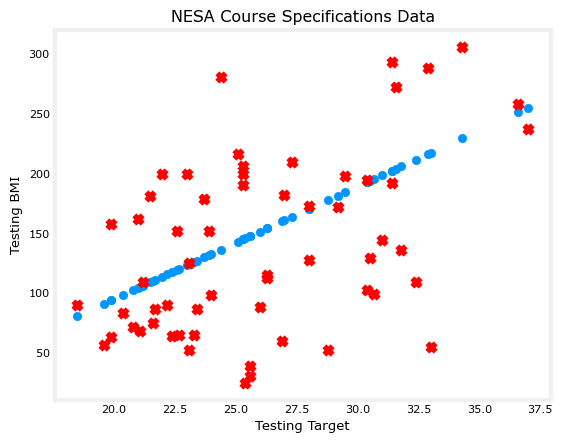

In [5]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [6]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.17409480986663017


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [7]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

     DoB    DoT  Predicted result        Loss
0   32.4  109.0        211.587461  10524.7081
1   21.5  181.0        109.150471   5162.4225
2   22.4   64.0        117.608572   2874.0321
3   23.0  200.0        123.247305   5890.5625
4   31.4  192.0        202.189572    103.8361
5   20.4   83.0         98.812794    249.9561
6   33.0   55.0        217.226195  26318.5729
7   37.0  237.0        254.817751    317.5524
8   31.6  272.0        204.069150   4614.4849
9   22.0  200.0        113.849416   7421.8225
10  28.0  173.0        170.236750      7.6176
11  21.2  109.0        106.331105      7.1289
12  26.3  115.0        154.260339   1541.3476
13  22.2   90.0        115.728994    662.0329
14  21.6   75.0        110.090260   1231.3081
15  36.6  258.0        251.058595     48.1636
16  25.6   31.0        147.681816  13614.2224
17  31.0  144.0        198.430417   2962.6249
18  30.4  103.0        192.791683   8062.2441
19  32.9  288.0        216.286406   5142.3241
20  31.8  136.0        205.948728 

You may want to do some manual predictions to understand your model.

In [8]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[-91.96435303]
[-83.50625294]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [9]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: -92.90414192788006
Coefficient: [9.39788899]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [10]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [11]:
mx_col = ['BMI','BP','FDR']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

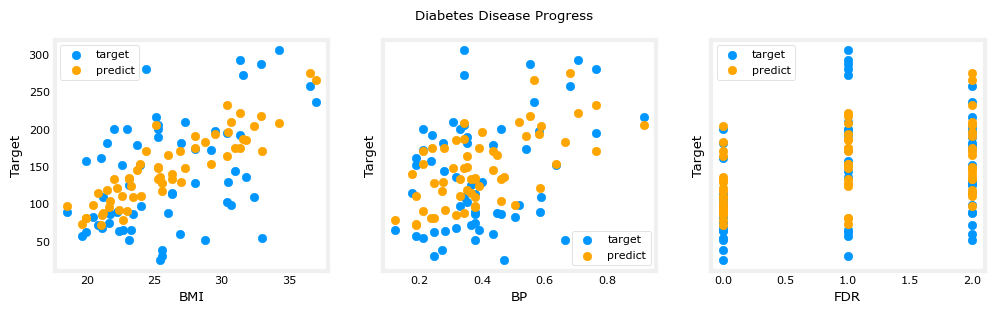

In [12]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

In [13]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.2753767563145235


In [14]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

[-106.00676849]
[-46.31417731]


In [15]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 1919.4728703389828
     BMI        BP  FDR  Target  Predicted result        Loss
0   32.4  0.588235  0.0   109.0        204.586077   9137.4481
1   21.5  0.352941  2.0   181.0        118.954291   3850.2025
2   22.4  0.282353  0.0    64.0         92.410150    807.1281
3   23.0  0.211765  0.0   200.0         90.171548  12062.6289
4   31.4  0.239176  1.0   192.0        174.625442    301.7169
5   20.4  0.505882  0.0    83.0         98.685762    246.1761
6   33.0  0.211765  0.0    55.0        171.501163  13572.2500
7   37.0  0.564706  2.0   237.0        266.370334    862.5969
8   31.6  0.341176  1.0   272.0        186.538093   7303.4116
9   22.0  0.458824  2.0   200.0        133.698341   4395.6900
10  28.0  0.541176  2.0   173.0        190.800887    316.8400
11  21.2  0.341176  0.0   109.0         88.582579    416.9764
12  26.3  0.176471  2.0   115.0        140.196558    635.0400
13  22.2  0.584353  0.0    90.0        121.238358    975.9376
14  21.6 

In [16]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: -118.24170689737355
Coefficient: [  8.13296157 100.84370903  13.3727135 ]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [17]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

In [18]:
mx_col = ['BMI']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [19]:
poly_features = poly.fit_transform(mx_test)

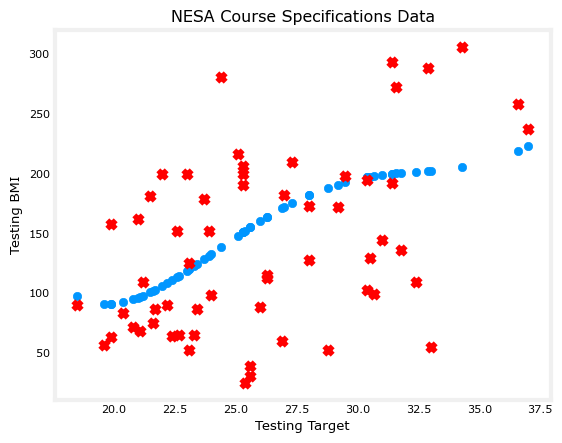

In [20]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

In [21]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.13055402893015822


In [22]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

[6547.73351915]


In [23]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 2303.1243398305087
     BMI  Target  Predicted result        Loss
0   32.4   109.0        201.601180   8574.7600
1   21.5   181.0        100.580037   6467.3764
2   22.4    64.0        110.690954   2179.9561
3   23.0   200.0        118.525839   6637.3609
4   31.4   192.0        199.721093     59.5984
5   20.4    83.0         92.534522     90.8209
6   33.0    55.0        202.505334  21759.2001
7   37.0   237.0        223.248116    189.0625
8   31.6   272.0        200.165625   5159.5489
9   22.0   200.0        105.900633   8854.8100
10  28.0   173.0        181.832191     77.9689
11  21.2   109.0         97.826683    124.7689
12  26.3   115.0        163.856839   2387.2996
13  22.2    90.0        108.244221    332.6976
14  21.6    75.0        101.575760    706.4964
15  36.6   258.0        218.653691   1548.4225
16  25.6    31.0        154.916679  15356.1664
17  31.0   144.0        198.688346   2990.9961
18  30.4   103.0        196.705197   8781.5641

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.